# ML Package Demo: KNN and Linear Regression

This notebook demonstrates the custom `mlpackage` library built from scratch for this project. We will apply two supervised learning algorithms to the classic Iris dataset:

- **K-Nearest Neighbors (KNN)** — a classification algorithm
- **Linear Regression** — a regression algorithm

Each section includes an explanation of the math and intuition behind the algorithm, followed by a hands-on demonstration using our custom implementations.

## 1. Imports and Setup

We begin by importing our custom package alongside standard data science libraries. Since this notebook lives inside the `notebooks/` folder, we first add the parent directory to Python's path so it can locate `mlpackage`. `numpy` handles numerical operations, `matplotlib` handles plotting, and `sklearn` is used only for loading the dataset and splitting it — not for modeling.

In [4]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

from mlpackage.supervised_learning.knn import KNN
from mlpackage.supervised_learning.linear_regression import LinearRegression

## 2. The Iris Dataset

The Iris dataset is one of the most well-known datasets in machine learning. It contains 150 samples of iris flowers, each described by 4 features:

- Sepal length (cm)
- Sepal width (cm)
- Petal length (cm)
- Petal width (cm)

Each sample belongs to one of three species: **Setosa**, **Versicolor**, or **Virginica**. The goal is to predict the species from the measurements.

Let's load and explore the data.

In [5]:
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

df = pd.DataFrame(X, columns=feature_names)
df['species'] = [target_names[i] for i in y]
print(f'Dataset shape: {X.shape}')
print(f'Classes: {target_names}')
df.head(10)

Dataset shape: (150, 4)
Classes: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


### 2.1 Data Exploration

Before modeling, it's important to understand the distribution of the data. Below we plot petal length vs petal width colored by species — these two features tend to be the most separable.

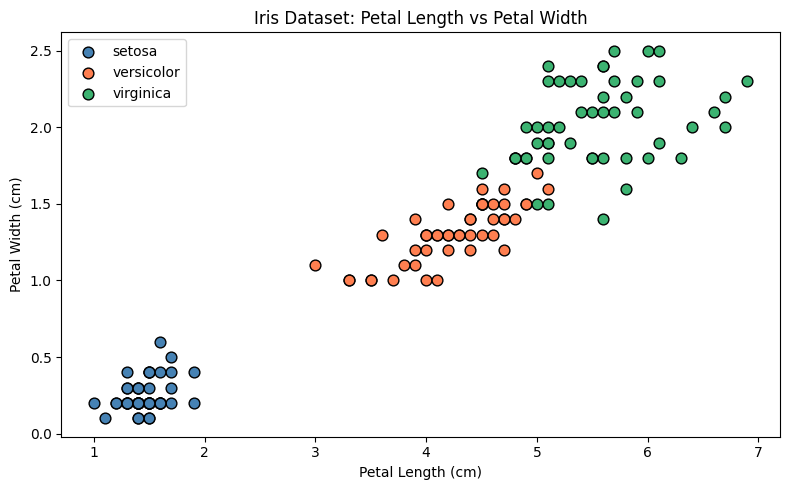

In [6]:
colors = ['steelblue', 'coral', 'mediumseagreen']

plt.figure(figsize=(8, 5))
for i, species in enumerate(target_names):
    mask = y == i
    plt.scatter(X[mask, 2], X[mask, 3], label=species, color=colors[i], edgecolors='k', s=60)

plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Iris Dataset: Petal Length vs Petal Width')
plt.legend()
plt.tight_layout()
plt.show()

### 2.2 Train/Test Split

We split the data into a **training set** (80%) and a **test set** (20%). The model learns only from the training set. The test set is held out and used exclusively to evaluate how well the model generalizes to unseen data.

Setting `random_state=42` ensures the split is reproducible — anyone running this notebook will get the same split.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Training samples: {X_train.shape[0]}')
print(f'Test samples:     {X_test.shape[0]}')

Training samples: 120
Test samples:     30


## 3. K-Nearest Neighbors (KNN)

### 3.1 Algorithm Intuition

KNN is one of the simplest machine learning algorithms. The core idea is:

> *To classify a new data point, look at the K training points closest to it and take a majority vote.*

There is no explicit "training" step — the model simply memorizes the training data and does all its work at prediction time. This is called a **lazy learner**.

### 3.2 The Math: Euclidean Distance

To find the "closest" neighbors, we measure distance. The most common metric is **Euclidean distance**, which is the straight-line distance between two points in n-dimensional space:

$$d(a, b) = \sqrt{\sum_{i=1}^{n}(a_i - b_i)^2}$$

For example, if two flowers have measurements $a = [5.1, 3.5, 1.4, 0.2]$ and $b = [4.9, 3.0, 1.4, 0.2]$, the distance between them is:

$$d = \sqrt{(5.1-4.9)^2 + (3.5-3.0)^2 + (1.4-1.4)^2 + (0.2-0.2)^2} \approx 0.539$$

### 3.3 Choosing K

- A **small K** (e.g. K=1) makes the model sensitive to noise — it overfits.
- A **large K** smooths out the decision boundary but may underfit.
- K=3 to K=7 is a common starting point for small datasets.

### 3.4 Training and Prediction

In [8]:
knn = KNN(k=3)
knn.fit(X_train, y_train)

accuracy = knn.accuracy(X_test, y_test)
print(f'KNN Accuracy (k=3): {accuracy:.4f}')

KNN Accuracy (k=3): 1.0000


### 3.5 Confusion Matrix

A confusion matrix shows us exactly where the model is making mistakes. Each row represents the true class, and each column represents what the model predicted. A perfect model has all values on the diagonal.

In [9]:
cm = knn.confusion_matrix(X_test, y_test)
cm.index = target_names
cm.columns = target_names
print('Confusion Matrix:')
print(cm)

Confusion Matrix:
            setosa  versicolor  virginica
setosa          10           0          0
versicolor       0           9          0
virginica        0           0         11


### 3.6 Effect of K on Accuracy

Let's see how accuracy changes as we vary K. This helps us understand the bias-variance tradeoff.

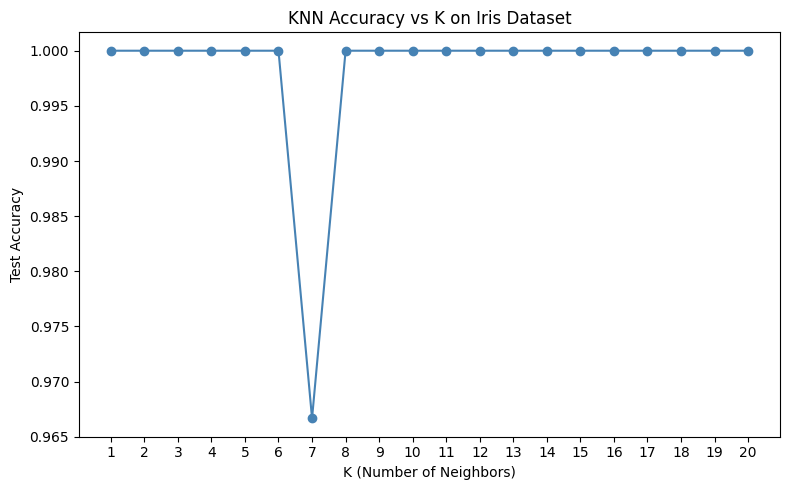

In [10]:
k_values = range(1, 21)
accuracies = []

for k in k_values:
    model = KNN(k=k)
    model.fit(X_train, y_train)
    accuracies.append(model.accuracy(X_test, y_test))

plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o', color='steelblue')
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Test Accuracy')
plt.title('KNN Accuracy vs K on Iris Dataset')
plt.xticks(k_values)
plt.tight_layout()
plt.show()

### 3.7 Decision Boundary

To visualize how KNN partitions the feature space, we plot the decision boundary using only the two most informative features: petal length and petal width.

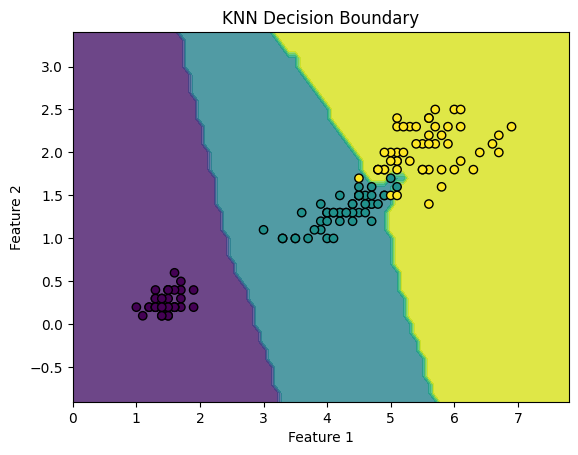

In [11]:
X_2d = X[:, 2:4]  # petal length and petal width only
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(X_2d, y, test_size=0.2, random_state=42)

knn_2d = KNN(k=3)
knn_2d.fit(X_train_2d, y_train_2d)
knn_2d.draw_decision_boundary(X_2d, y)

## 4. Linear Regression on Iris

### 4.1 Algorithm Intuition

While KNN is a classifier, **Linear Regression** is a regression algorithm — it predicts a continuous numeric value rather than a class label.

We'll use it here to predict **petal width** from **petal length**, which is a continuous target. This lets us demonstrate the algorithm on the same dataset.

The model fits a straight line through the data:

$$\hat{y} = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \cdots + \theta_n x_n$$

Where $\theta_0$ is the intercept (bias) and $\theta_1 \ldots \theta_n$ are the coefficients (slopes) for each feature.

### 4.2 The Math: Normal Equation

Instead of iteratively adjusting parameters (like gradient descent), our implementation uses the **Normal Equation** — a closed-form solution that directly computes the optimal parameters:

$$\theta = (X^T X)^+ X^T y$$

Where $(\cdot)^+$ denotes the pseudoinverse, which handles cases where $X^T X$ is not invertible. This gives us the exact answer in one step.

### 4.3 Evaluation Metrics

We evaluate using two metrics:

- **RMSE (Root Mean Squared Error)**: Average prediction error in the same units as the target. Lower is better.
$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

- **R² (Coefficient of Determination)**: How much variance in the target is explained by the model. 1.0 = perfect fit, 0.0 = no better than predicting the mean.
$$R^2 = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$$

### 4.4 Training and Evaluation

In [12]:
# Predict petal width (column 3) from petal length (column 2)
X_reg = X[:, 2].reshape(-1, 1)  # petal length
y_reg = X[:, 3]                  # petal width

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

lr = LinearRegression()
lr.fit(X_reg_train, y_reg_train)

print(f'Intercept:    {lr.intercept:.4f}')
print(f'Coefficient:  {lr.coefficients[0]:.4f}')
print(f'RMSE:         {lr.rmse(X_reg_test, y_reg_test):.4f}')
print(f'R²:           {lr.R_squared(X_reg_test, y_reg_test):.4f}')

Intercept:    -0.3567
Coefficient:  0.4132
RMSE:         0.2136
R²:           0.9283


### 4.5 Visualizing the Regression Line

Let's plot the data points alongside the fitted regression line to see how well the model captures the relationship between petal length and petal width.

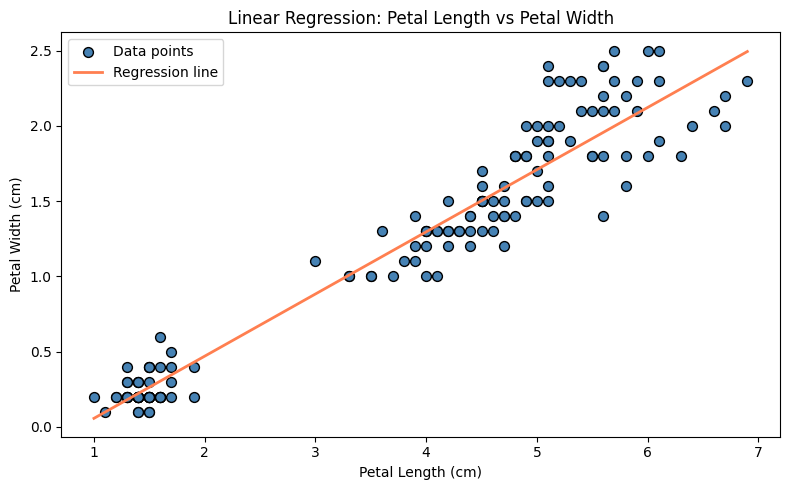

In [13]:
X_line = np.linspace(X_reg.min(), X_reg.max(), 100).reshape(-1, 1)
y_line = lr.predict(X_line)

plt.figure(figsize=(8, 5))
plt.scatter(X_reg, y_reg, color='steelblue', edgecolors='k', s=50, label='Data points')
plt.plot(X_line, y_line, color='coral', linewidth=2, label='Regression line')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Linear Regression: Petal Length vs Petal Width')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Summary

| Algorithm | Task | Dataset | Key Metric | Result |
|---|---|---|---|---|
| KNN (k=3) | Classification | Iris (all features) | Accuracy | See above |
| Linear Regression | Regression | Iris (petal length → petal width) | R² / RMSE | See above |

Both algorithms were implemented from scratch in `mlpackage` without using scikit-learn's model implementations. This demonstrates that even simple algorithms, when implemented correctly, can achieve strong performance on well-structured datasets.

Key takeaways:
- KNN is intuitive and requires no training, but slows down as the dataset grows since it computes distances at prediction time.
- Linear Regression finds the globally optimal solution in one step using the Normal Equation, but assumes a linear relationship between features and target.